# Bag of Visual Words demo on calltech101 dataset

This notebook trains and evaluates a Bag of Visual Words classifier on balanced calltech101. All classes have 25 images for training and 6 for testing. The dataset is stored as .zip file in the project directory. To use it for trainig extract it first.

You can switch the feature extractor by changing the `feature_extractor` variable in the next code cell. Supported options include `SIFT`, `SURF` when available, `ORB`, `AKAZE`, `BRISK`, and `KAZE`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from bovw import BagOfVisualWordsClassifier, BoVWConfig

plt.rcParams['figure.dpi'] = 120

In [ ]:
dataset_root = Path('caltech101_balanced')
feature_extractor = 'SIFT'  # change to ORB, AKAZE, BRISK, KAZE, or SURF if available
vocabulary_size = 1024

config = BoVWConfig(
    feature_extractor=feature_extractor,
    vocabulary_size=vocabulary_size,
    max_descriptors_per_image=250,
    max_vocabulary_descriptors=10000000,
    random_state=42,
)
model = BagOfVisualWordsClassifier(config)
model.supported_extractors()

['SIFT', 'SURF', 'ORB', 'AKAZE', 'BRISK', 'KAZE']

In [26]:
model.fit(dataset_root / 'train')
metrics = model.evaluate(dataset_root / 'test')
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(metrics['classification_report'])

Accuracy: 0.2941
                   precision    recall  f1-score   support

BACKGROUND_Google       0.20      0.17      0.18         6
            Faces       0.14      0.17      0.15         6
       Faces_easy       0.29      0.33      0.31         6
         Leopards       0.56      0.83      0.67         6
       Motorbikes       0.67      1.00      0.80         6
        accordion       0.36      0.67      0.47         6
        airplanes       0.67      0.67      0.67         6
           anchor       0.33      0.33      0.33         6
              ant       0.14      0.17      0.15         6
           barrel       0.00      0.00      0.00         6
             bass       0.14      0.17      0.15         6
           beaver       0.00      0.00      0.00         6
        binocular       0.25      0.17      0.20         6
           bonsai       0.33      0.33      0.33         6
            brain       0.50      0.50      0.50         6
     brontosaurus       0.14      0.17

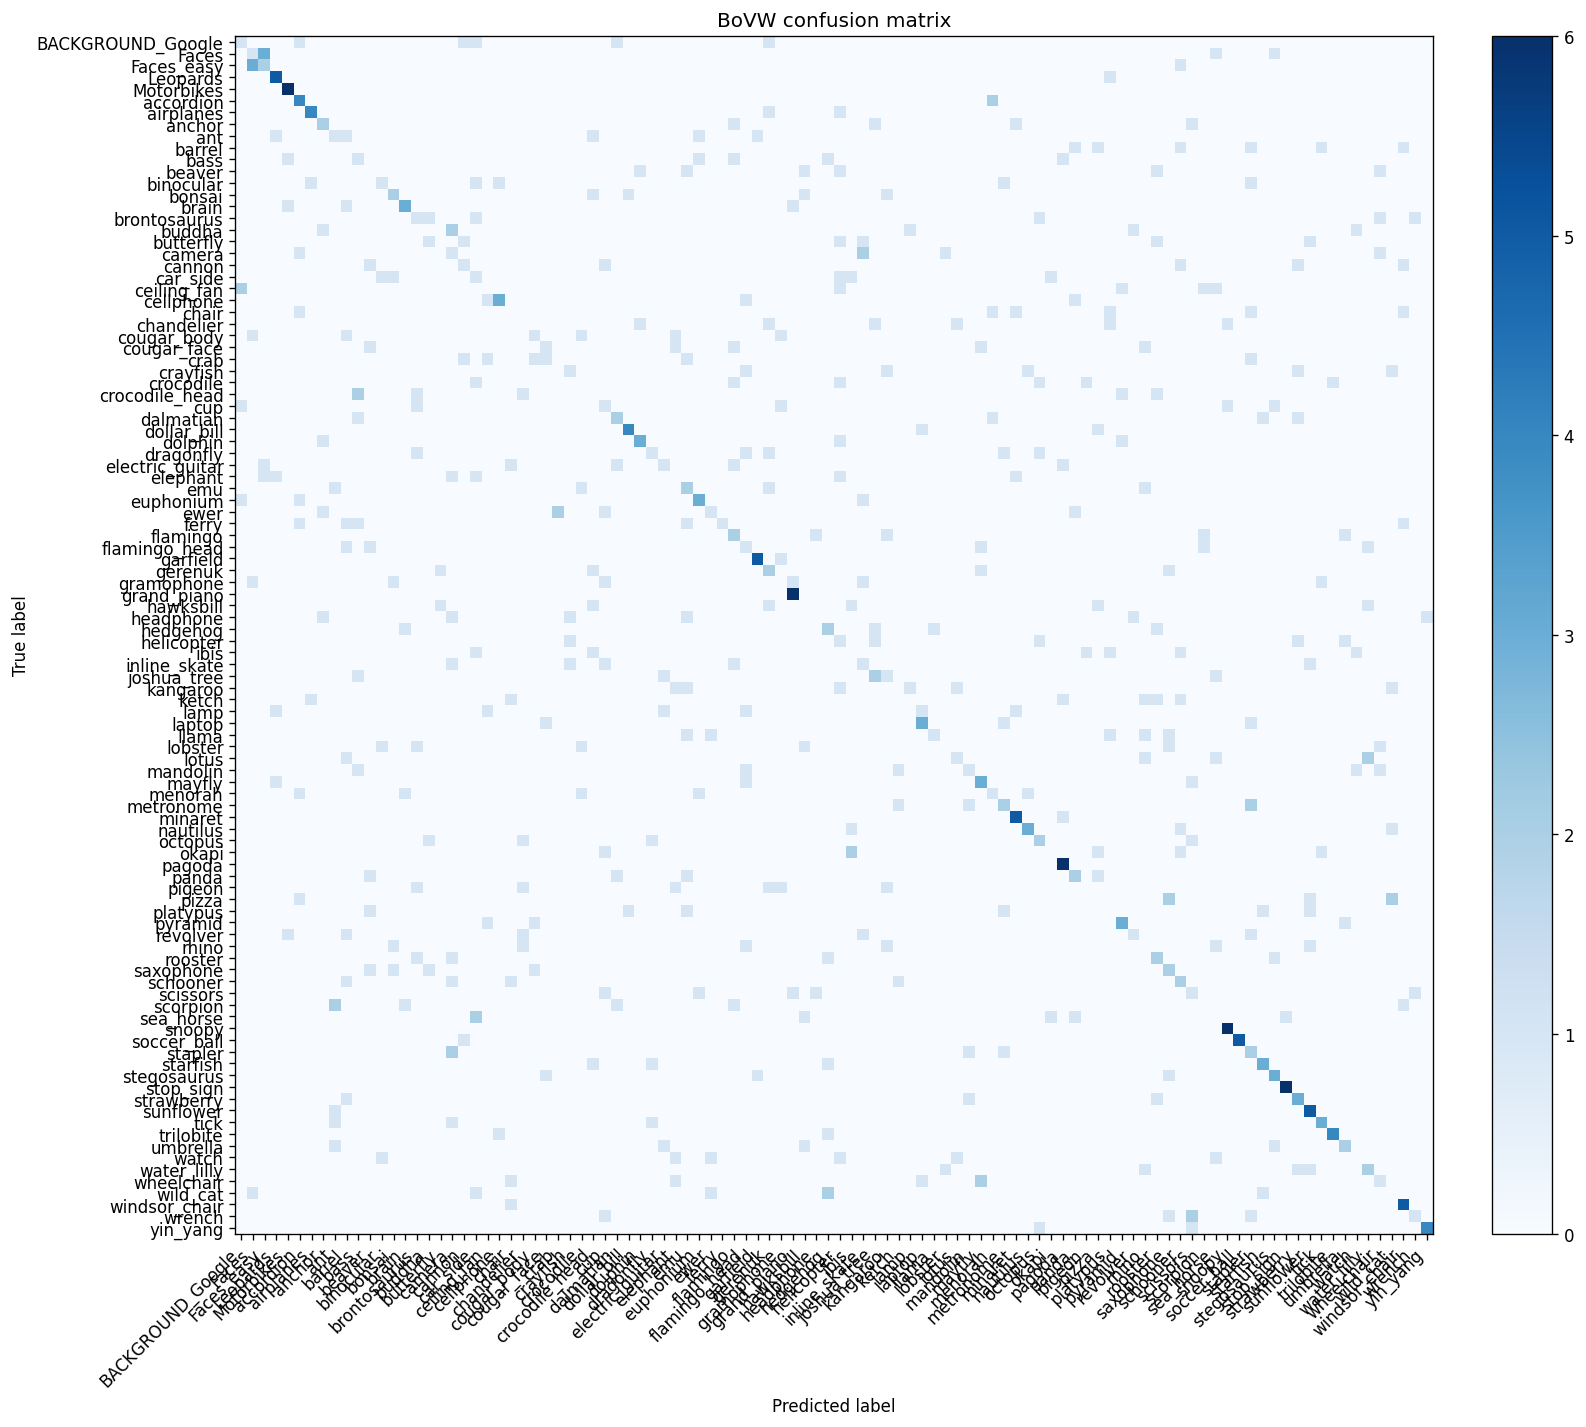

In [27]:
confusion = metrics['confusion_matrix']
labels = model.class_names

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(confusion, cmap='Blues')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('BoVW confusion matrix')

# for row in range(confusion.shape[0]):
#     for col in range(confusion.shape[1]):
#         ax.text(col, row, int(confusion[row, col]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

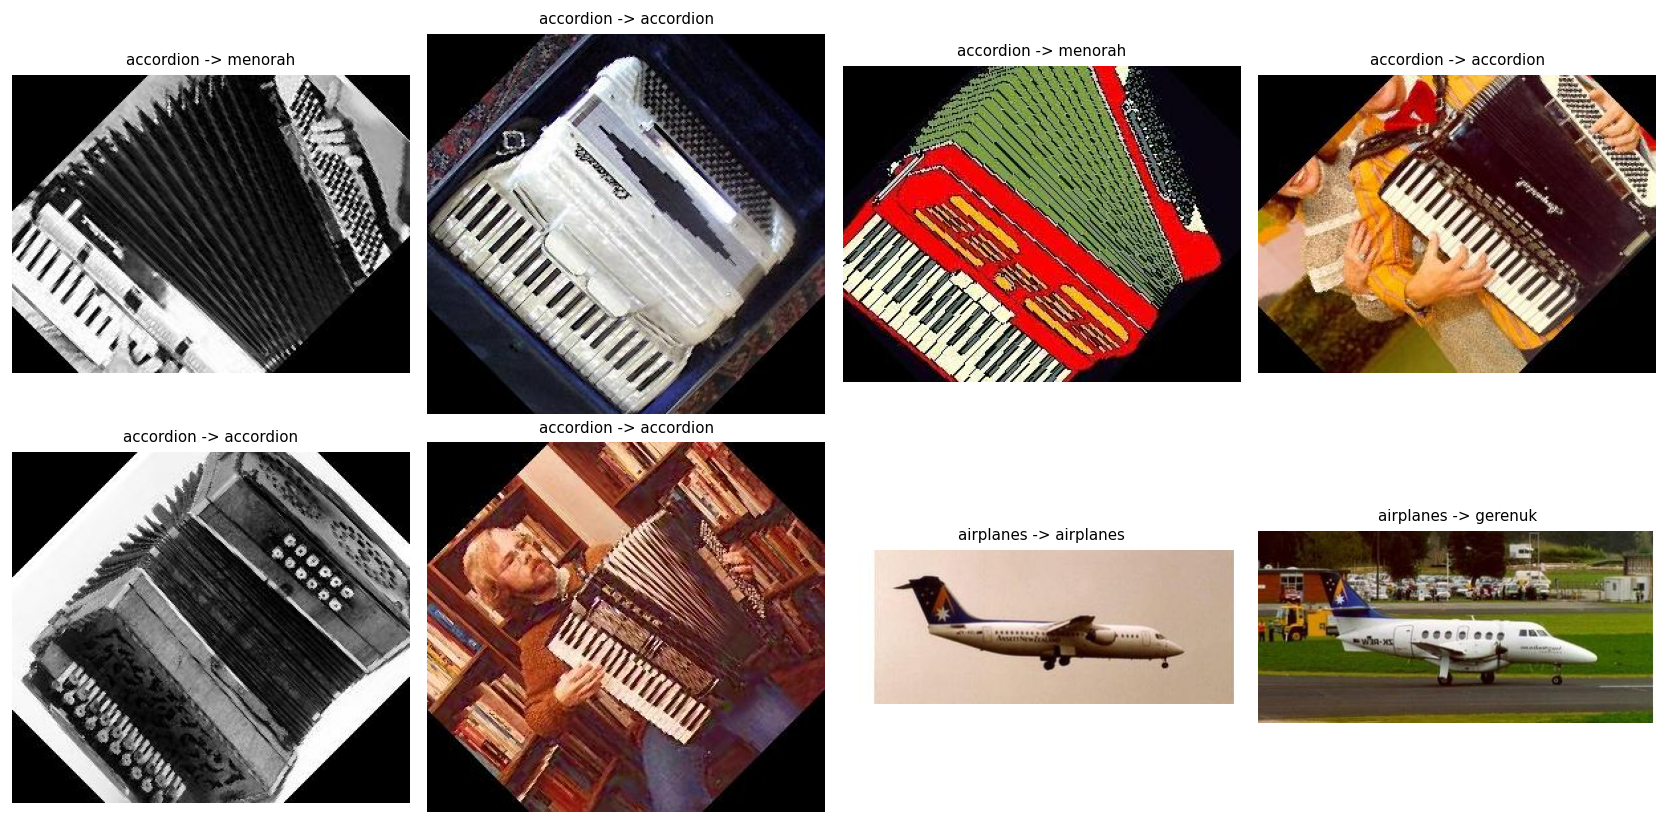

In [28]:
test_paths = metrics['image_paths']
y_true = metrics['y_true']
y_pred = metrics['y_pred']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for ax, image_path, truth, pred in zip(axes, test_paths[:8], y_true[:8], y_pred[:8]):
    image = plt.imread(str(image_path))
    if image.ndim == 2:
        ax.imshow(image, cmap='gray')
    else:
        ax.imshow(image)
    ax.set_title(f'{truth} -> {pred}', fontsize=9)
    ax.axis('off')

for ax in axes[len(test_paths[:8]):]:
    ax.axis('off')

plt.tight_layout()
plt.show()